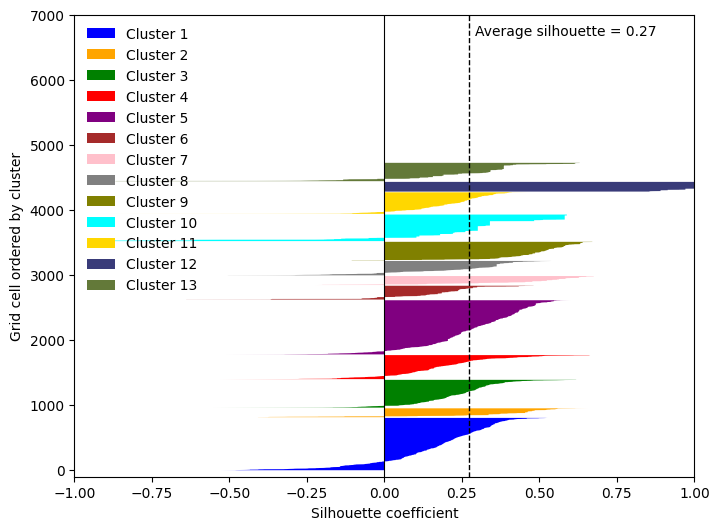

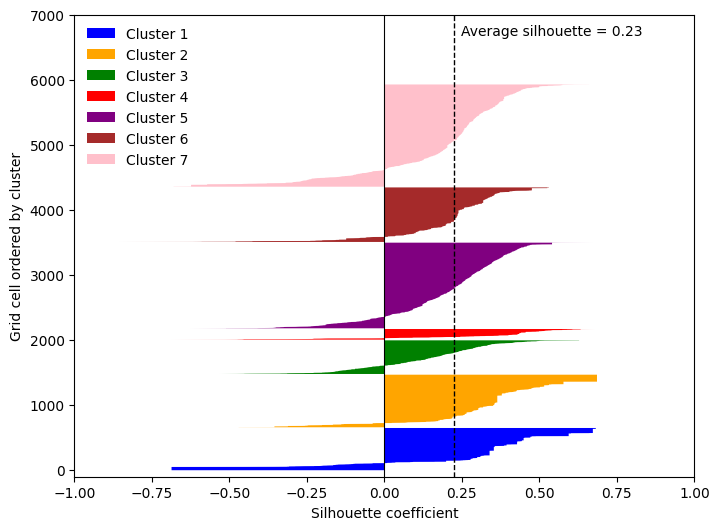

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.patches import Patch
from pathlib import Path
from datetime import datetime

def func_silhouette(scenario, cell_size, threshold):

    # ============================================================
    # Path settings
    # ============================================================
    base_dir = Path(
        f'output/scenario={scenario}/cell={int(cell_size / 1e3)}km/threshold={threshold}'
    )

    beta_path = base_dir / f'{scenario}_{int(cell_size / 1e3)}km_{threshold}_beta_diversity_matrix.xlsx'
    cluster_path = base_dir / f'cluster_number/{scenario}_{int(cell_size / 1e3)}km_{threshold}_grid_cluster.xlsx'

    # ============================================================
    # Read data
    # ============================================================
    beta_df = pd.read_excel(beta_path, index_col=0)
    cluster_df = pd.read_excel(cluster_path)

    cluster_labels = cluster_df['cluster'].values
    grid_indices = cluster_df['grid_index'].values

    # ============================================================
    # Validation
    # ============================================================
    assert beta_df.shape[0] == beta_df.shape[1], "beta_df must be square"
    assert beta_df.shape[0] == len(cluster_labels), "Label size mismatch"
    assert np.allclose(beta_df.values, beta_df.values.T), "beta_df must be symmetric"
    assert np.allclose(np.diag(beta_df.values), 0), "Diagonal must be zero"

    # ============================================================
    # Cluster colors (10 clusters)
    # ============================================================
    cluster_colors = {
        1: 'blue',
        2: 'orange', 
        3: 'green',
        4: 'red',
        5: 'purple', 
        6: 'brown',
        7: 'pink',
        8: 'gray', 
        9: 'olive',
        10: 'cyan',
        11: 'gold',
        12: '#393B79', 
        13: '#637939',
        14: '#8C6D31',
        15: '#843C39',
    }

    # ============================================================
    # Silhouette calculation
    # ============================================================
    sil_values = silhouette_samples(
        beta_df.values, cluster_labels, metric='precomputed'
    )
    sil_avg = silhouette_score(
        beta_df.values, cluster_labels, metric='precomputed'
    )

    # ============================================================
    # Save silhouette values
    # ============================================================
    out_df = pd.DataFrame({
        'grid_index': grid_indices,
        'cluster': cluster_labels,
        'silhouette_value': sil_values
    })
    out_df.to_excel(
        base_dir / f'cluster_number/{scenario}_{int(cell_size / 1e3)}km_{threshold}_silhouette.xlsx',
        index=False
    )

    # ============================================================
    # Plot silhouette figure
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 6))

    y_lower = 0
    gap = 10  # gap between clusters

    unique_clusters = np.sort(np.unique(cluster_labels))

    for cid in unique_clusters:
        vals = sil_values[cluster_labels == cid]
        vals.sort()

        size = len(vals)
        y_upper = y_lower + size

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, vals,
            facecolor=cluster_colors[cid],
            edgecolor='none',
            alpha=1
        )

        y_lower = y_upper + gap

    # ============================================================
    # Reference lines
    # ============================================================
    ax.axvline(
        sil_avg, linestyle='--', color='black', linewidth=1
    )
    ax.axvline(0, color='black', linewidth=0.8)

    # --- 标注 average silhouette 数值（写在图内） ---
    ax.text(
        sil_avg + 0.02,                # x 位置（稍微右移）
        7000 * 0.98,                # y 位置（图内靠上）
        f'Average silhouette = {sil_avg:.2f}',
        fontsize=10,
        ha='left',
        va='top'
    )

    ax.set_xlabel('Silhouette coefficient', fontsize=10)
    ax.set_ylabel('Grid cell ordered by cluster', fontsize=10)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-100, 7000)

    # ============================================================
    # Cluster legend —— 放到图内
    # ============================================================
    legend_patches = [
        Patch(facecolor=cluster_colors[cid], label=f'Cluster {cid}')
        for cid in unique_clusters
    ]

    ax.legend(
        handles=legend_patches,
        # title='Cluster',
        loc='upper left',          # 图内左上角
        frameon=False,
        # framealpha=0.85,           # 半透明背景
        fontsize=10,
        # title_fontsize=10
    )

    # ============================================================
    # Save figure
    # ============================================================
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    out_fig = base_dir / f'cluster_number/{scenario}_{int(cell_size / 1e3)}km_{threshold}_silhouette_{date_str}.tif'
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()


# ================================
# Example usage
# ================================
func_silhouette(scenario='all', cell_size=40000, threshold=5)
func_silhouette(scenario='all', cell_size=40000, threshold=1)

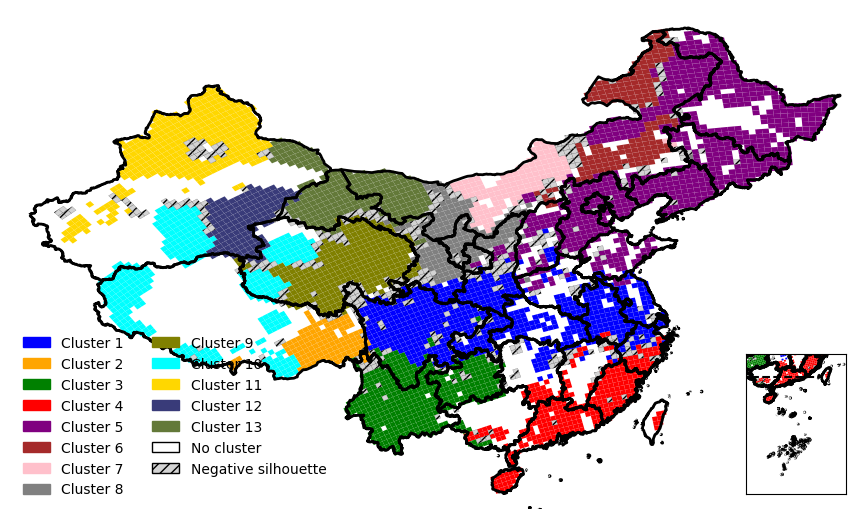

[INFO] Cluster map saved: output\scenario=all\cell=40km\threshold=5\cluster_number\all_40km_5_silhouette_map_20260110.tif


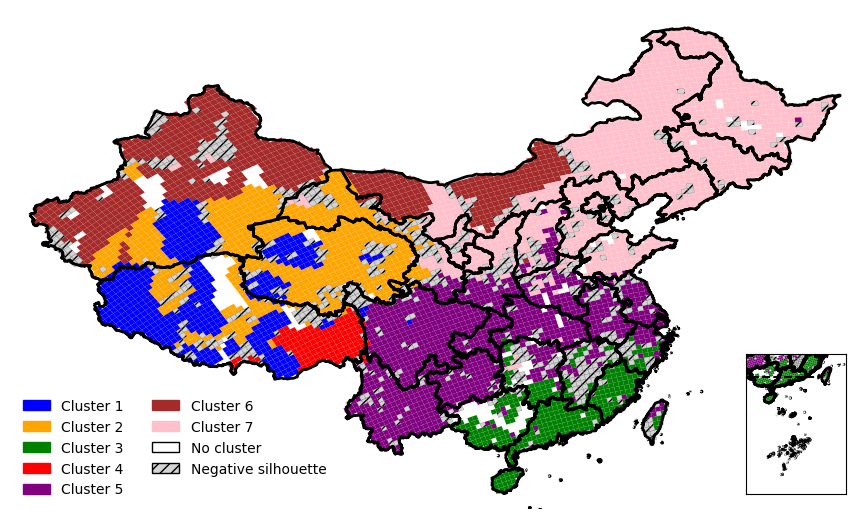

[INFO] Cluster map saved: output\scenario=all\cell=40km\threshold=1\cluster_number\all_40km_1_silhouette_map_20260110.tif


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import numpy as np
from datetime import datetime

# ======================================================
# 绘制聚类地图（主图 + 插图）函数
# ======================================================
def plot_cluster_map_and_dendrogram(scenario, cell_size, threshold):

    # ======================================================
    # 1. 构造文件路径
    # ======================================================
    cluster_file = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/threshold={threshold}/cluster_number/{scenario}_{cell_size//1000}km_{threshold}_silhouette.xlsx'
    )
    grid_shp_file = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/{scenario}_{cell_size//1000}km_grid_map.geojson'
    )

    # ======================================================
    # 2. 读取数据
    # ======================================================
    cluster_df = pd.read_excel(cluster_file)
    grid_gdf = gpd.read_file(grid_shp_file)

    # 合并聚类信息
    grid_gdf = grid_gdf.merge(cluster_df, on='grid_index', how='left')

    # ======================================================
    # 3. 设置 cluster 颜色
    # ======================================================
    cluster_colors = {
        1: 'blue',
        2: 'orange', 
        3: 'green',
        4: 'red',
        5: 'purple', 
        6: 'brown',
        7: 'pink',
        8: 'gray', 
        9: 'olive',
        10: 'cyan',
        11: 'gold',
        12: '#393B79', 
        13: '#637939',
        14: '#8C6D31',
        15: '#843C39',
    }

    grid_gdf['cluster'] = grid_gdf['cluster'].fillna(-1)
    clusters = sorted(grid_gdf.loc[grid_gdf['cluster'] != -1, 'cluster'].unique())

    # ======================================================
    # 4. 创建图和子图
    # ======================================================
    fig = plt.figure(figsize=(10, 10))
    ax_map = fig.add_axes([0, 0.5, 0.85, 0.5])
    ax_insert = fig.add_axes([0.74, 0.515, 0.1, 0.14])
    
    # ======================================================
    # 5. 绘制中国边界
    # ======================================================
    china = gpd.read_file('../0_map/中国_省.geojson')
    china = china[china['name'] != '境界线'].reset_index(drop=True)
    china_dissolved = china.dissolve()

    china.boundary.plot(ax=ax_map, color='black', linewidth=2)
    china.boundary.plot(ax=ax_insert, color='black', linewidth=2)

    # ======================================================
    # 6. 绘制 No cluster 的格子（灰色 + hatch）
    # ======================================================
    no_cluster_gdf = grid_gdf[grid_gdf['cluster'] == -1]

    for geom in no_cluster_gdf.geometry:
        if geom.geom_type == 'Polygon':
            polygons = [geom]
        elif geom.geom_type == 'MultiPolygon':
            polygons = geom.geoms
        else:
            continue

        for poly in polygons:
            ax_map.add_patch(
                mpatches.Polygon(
                    np.array(poly.exterior.coords),
                    facecolor='white',
                    linewidth=0.1
                )
            )
            ax_insert.add_patch(
                mpatches.Polygon(
                    np.array(poly.exterior.coords),
                    facecolor='white',
                    linewidth=0.1
                )
            )

    # ======================================================
    # 7. 绘制有 cluster 的格子，且silhouette值为正
    # ======================================================
    clustered_gdf = grid_gdf[(grid_gdf['cluster'] != -1) & (grid_gdf['silhouette_value']>0)].copy()
    clustered_gdf['color'] = clustered_gdf['cluster'].map(cluster_colors)

    clustered_gdf.plot(
        color=clustered_gdf['color'],
        linewidth=0.1,
        edgecolor='None',
        ax=ax_map
    )
    clustered_gdf.plot(
        color=clustered_gdf['color'],
        linewidth=0.1,
        edgecolor='None',
        ax=ax_insert
    )

    # ======================================================
    # 7.1 绘制有 cluster 的格子，且silhouette值为负
    # ======================================================
    clustered_gdf = grid_gdf[(grid_gdf['cluster'] != -1) & (grid_gdf['silhouette_value']<0)].copy()
    # clustered_gdf['color'] = clustered_gdf['cluster'].map(cluster_colors)

    clustered_gdf.plot(
        facecolor='lightgrey',
        edgecolor='black',
        hatch='///',
        linewidth=0.1,
        ax=ax_map
    )
    clustered_gdf.plot(
        facecolor='lightgrey',
        edgecolor='black',
        hatch='///',
        linewidth=0.1,
        ax=ax_insert
    )

    # ======================================================
    # 8. 自定义图例
    # ======================================================
    handles = [
        mpatches.Patch(color=cluster_colors[cl], label=f'Cluster {int(cl)}')
        for cl in clusters
    ]

    handles.append(
        mpatches.Patch(facecolor='white', label='No cluster', edgecolor='black')
    )

    handles.append(
        mpatches.Patch(facecolor='lightgrey', label='Negative silhouette', edgecolor='black', hatch='///')
    )

    ax_map.legend(
        handles=handles,
        loc='lower left',
        frameon=False,
        ncols=2
    )

    # ======================================================
    # 9. 地图样式设置
    # ======================================================
    ax_map.set_axis_off()
    # ax_map.hlines(23+26/60, 95, 126, color='black', linestyle='--')
    ax_map.set_xlim(72, 136)
    ax_map.set_ylim(17, 55)
    ax_map.set_aspect('equal')
    ax_insert.set_xticks([])
    ax_insert.set_yticks([])
    ax_insert.set_xlim(105, 125)
    ax_insert.hlines(23+26/60, 95, 120, color='black', linestyle='--')
    ax_insert.set_ylim(0, 28)
    ax_insert.set_aspect('equal')

    # ======================================================
    # 10. 保存图像
    # ======================================================
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    save_map_path = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/threshold={threshold}/cluster_number/{scenario}_{int(cell_size/1e3)}km_{threshold}_silhouette_map_{date_str}.tif'
    )
    save_map_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_map_path, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    print(f'[INFO] Cluster map saved: {save_map_path}')


# ================================
# Example usage
# ================================
plot_cluster_map_and_dendrogram(scenario='all', cell_size=40000, threshold=5)
plot_cluster_map_and_dendrogram(scenario='all', cell_size=40000, threshold=1)